In [16]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [17]:
df = pd.read_csv('../csv/churn_prediction.csv')

In [18]:
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [19]:
df.shape

(28382, 21)

In [20]:
df.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
gender                             object
dependents                        float64
occupation                         object
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                   object
dtype: object

In [31]:
df.columns

Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn',
       'last_transaction', 'doy_last_transc', 'moy_last_transc',
       'dow_last_transc'],
      dtype='object')

In [22]:
#Extract essential information from date column

In [23]:
date = pd.DatetimeIndex(df['last_transaction'])

In [24]:
#last_day of the year when transaction was done
df['doy_last_transc'] = date.dayofyear

In [27]:
#month of year when last transaction was done
df['moy_last_transc'] = date.month

In [29]:
#day of week when the last transaction was done
df['dow_last_transc'] = date.dayofweek

In [30]:
df[['last_transaction', 'doy_last_transc', 'moy_last_transc', 'dow_last_transc']]

,last_transaction,doy_last_transc,moy_last_transc,dow_last_transc
0,2019-05-21,141.0,5.0,1.0
1,2019-11-01,305.0,11.0,4.0
2,NaT,NaN,NaN,NaN
3,2019-08-06,218.0,8.0,1.0
4,2019-11-03,307.0,11.0,6.0
...,...,...,...,...
28377,2019-10-22,295.0,10.0,1.0
28378,2019-12-17,351.0,12.0,1.0
28379,2019-12-31,365.0,12.0,1.0
28380,NaT,NaN,NaN,NaN


In [38]:
#Let's check out the mean values of a few columns

In [35]:
print(f"mean of age: {df['age'].mean()}")
print(f"mean of age of people likely to churn: {df[df['churn']==1]['age'].mean()}")

mean of age: 48.208336269466564
mean of age of people likely to churn: 47.461216730038025


In [37]:
print(f"current balance mean: {df['current_balance'].mean()}")
print(f"mean of current balance of people who are likely to churn: {df[df['churn']==1]['current_balance'].mean()}")

current balance mean: 7380.55180360792
mean of current balance of people who are likely to churn: 5220.884321292776


In [39]:
#Let's check out the median values of a few columns

In [41]:
print(df['age'].median())

46.0


In [42]:
#Since mean and median are close to each other, hence we can say that the dataset is uniform!

In [ ]:
#Calculating std and var

In [45]:
print(df['current_balance'].std())

42598.711923233204


In [46]:
print(df['current_balance'].var())

1814650257.5186107


In [47]:
#A very handy feature -> describe

In [48]:
df.describe()

,customer_id,vintage,age,dependents,city,customer_nw_category,branch_code,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,doy_last_transc,moy_last_transc,dow_last_transc
count,28382.000000,28382.000000,28382.000000,25919.000000,27579.000000,28382.000000,28382.000000,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,2.838200e+04,28382.000000,25159.000000,25159.000000,25159.000000
mean,15143.508667,2091.144105,48.208336,0.347236,796.109576,2.225530,925.975019,7.380552e+03,7.495771e+03,7.496780e+03,7.124209e+03,3.433252e+03,3.261694e+03,3.658745e+03,3.339761e+03,7.451133e+03,7.495177e+03,0.185329,295.045709,10.142255,3.042728
std,8746.454456,272.676775,17.807163,0.997661,432.872102,0.660443,937.799129,4.259871e+04,4.252935e+04,4.172622e+04,4.457581e+04,7.707145e+04,2.968889e+04,5.198542e+04,2.430111e+04,4.203394e+04,4.243198e+04,0.388571,86.284356,2.788671,1.712724
min,1.000000,73.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-5.503960e+03,-3.149570e+03,1.428690e+03,-1.650610e+04,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,-3.374180e+03,-5.171920e+03,0.000000,1.000000,1.000000,0.000000
25%,7557.250000,1958.000000,36.000000,0.000000,409.000000,2.000000,176.000000,1.784470e+03,1.906000e+03,2.180945e+03,1.832507e+03,3.100000e-01,3.300000e-01,4.100000e-01,4.100000e-01,1.996765e+03,2.074407e+03,0.000000,270.000000,9.000000,1.000000
50%,15150.500000,2154.000000,46.000000,0.000000,834.000000,2.000000,572.000000,3.281255e+03,3.379915e+03,3.542865e+03,3.359600e+03,6.100000e-01,6.300000e-01,9.193000e+01,1.099600e+02,3.447995e+03,3.465235e+03,0.000000,335.000000,12.000000,3.000000
75%,22706.750000,2292.000000,60.000000,0.000000,1096.000000,3.000000,1440.000000,6.635820e+03,6.656535e+03,6.666887e+03,6.517960e+03,7.072725e+02,7.492350e+02,1.360435e+03,1.357553e+03,6.667958e+03,6.654693e+03,0.000000,354.000000,12.000000,5.000000
max,30301.000000,2476.000000,90.000000,52.000000,1649.000000,3.000000,4782.000000,5.905904e+06,5.740439e+06,5.700290e+06,5.010170e+06,1.226985e+07,2.361808e+06,7.637857e+06,1.414168e+06,5.778185e+06,5.720144e+06,1.000000,365.000000,12.000000,6.000000


In [49]:
# Let's plot and visualize some of the things here:

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

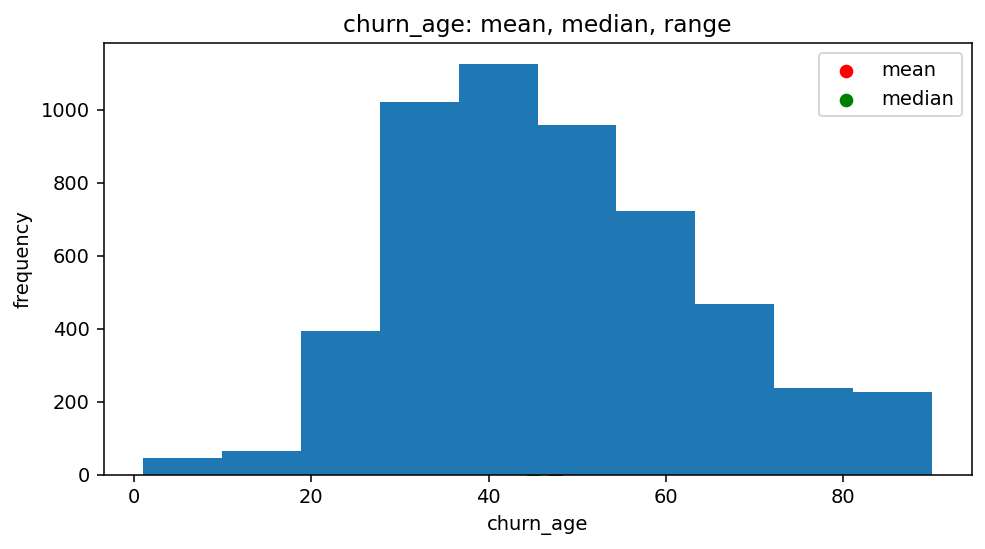

In [51]:
#set image resolution
plt.figure(figsize = (8,4), dpi = 140)

#plotting the histogram
plt.scatter(df[df['churn']==1]['age'].mean(), 0, label='mean', color='red')
plt.scatter(df[df['churn']==1]['age'].median(), 0, label='median', color='green')
plt.hist(df[df['churn']==1]['age'], bins=10)

#axes labels
plt.xlabel('churn_age')
plt.ylabel('frequency')
plt.title('churn_age: mean, median, range')
plt.legend()

In [59]:
# let's look at min and max values:
print(f"minimum balance listed: {df['current_balance'].min()}")
print(f"maximum balance listed: {df['current_balance'].max()}")

minimum balance listed: -5503.96
maximum balance listed: 5905904.03


In [61]:
# Let's calculate the age range
print(f"min_age: {df['age'].min()}, max_age: {df['age'].max()}")

min_age: 1, max_age: 90


# Now let's start the Univariate analysis

In [63]:
#First we will select all the numerical columns for our cause

In [64]:
data = df[['customer_id', 'vintage', 'age', 'dependents', 'current_balance', 'previous_month_end_balance', 'average_monthly_balance_prevQ',
          'average_monthly_balance_prevQ2', 'current_month_credit', 'previous_month_credit', 'current_month_debit', 'previous_month_debit',
          'current_month_balance', 'previous_month_balance', 'doy_last_transc', 'moy_last_transc', 'dow_last_transc']]

In [65]:
data.head()

,customer_id,vintage,age,dependents,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,doy_last_transc,moy_last_transc,dow_last_transc
0,1,2101,66,0.0,1458.71,1458.71,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,141.0,5.0,1.0
1,2,2348,35,0.0,5390.37,8704.66,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,305.0,11.0,4.0
2,4,2194,31,0.0,3913.16,5815.29,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,NaN,NaN,NaN
3,5,2329,90,NaN,2291.91,2291.91,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,218.0,8.0,1.0
4,6,1579,42,2.0,927.72,1401.72,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,307.0,11.0,6.0


In [78]:
# custom function to compute the univariate analysis

def UVA_numeric(data, var_group):

    size = len(var_group)
    plt.figure(figsize = (7*size,3), dpi = 100)

    #looping for each variable
    for j,i in enumerate(var_group):

        #calculating the descriptive properties of variables
        min_val = data[i].min()
        max_val = data[i].max()
        ran = data[i].max() - data[i].min()
        mean = data[i].mean()
        median = data[i].median()
        st_dev = data[i].std()
        skew = data[i].skew()
        kurt = data[i].kurt()

        #calculating points of standard deviation
        points = mean - st_dev, mean + st_dev

        #plotting the variable with every information
        plt.subplot(1,size,j+1)
        sns.kdeplot(data[i], fill = True)
        sns.lineplot(x=points, y=[0,0], color = 'black', label = 'std_dev')
        sns.scatterplot(x=[min_val,max_val], y=[0,0], color = 'orange', label = 'min/max')
        sns.scatterplot(x=[mean], y=[0], color='red', label='mean')
        sns.scatterplot(x=[median], y=[0], color='blue', label='median')
        plt.xlabel('{}'.format(i), fontsize = 20)
        plt.ylabel('density')
        plt.title(f'std_dev = {(round(points[0],2),round(points[1],2))}; kurtosis = {round(kurt,2)};\nskew = {round(skew,2)}; range = {round(ran,2)}\nmean = {round(mean,2)}; median = {round(median,2)}')

In [79]:
#groupling customers into specific groups:
customer_details = ['customer_id' , 'age' , 'vintage']

/Users/anujkumaryadav/Desktop/Jupyter_projects/myenv/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: divide by zero encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/Users/anujkumaryadav/Desktop/Jupyter_projects/myenv/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: overflow encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/Users/anujkumaryadav/Desktop/Jupyter_projects/myenv/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: invalid value encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/Users/anujkumaryadav/Desktop/Jupyter_projects/myenv/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: divide by zero encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/Users/anujkumaryadav/Desktop/Jupyter_projects/myenv/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: overflow encountered in 

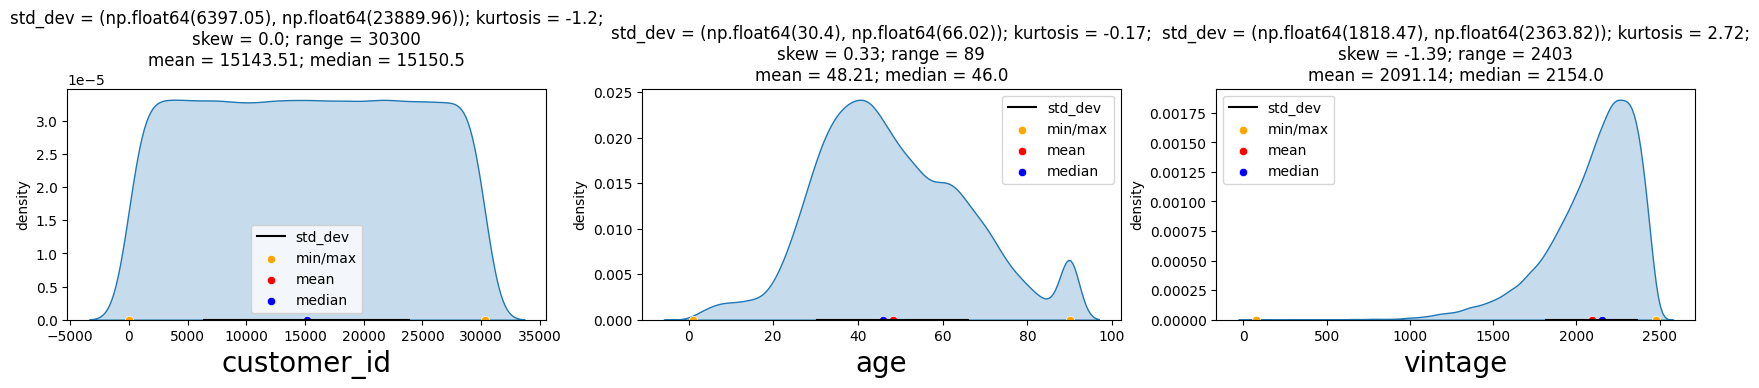

In [80]:
UVA_numeric(data, customer_details)

#### Similarly, we can create multiple groups and do the univariate analysis of the variables

# Now let's look forward to Bivariate analysis